# RQ4 — Longitudinal code-quality analysis of six AI-intensive projects

This notebook audits and analyzes the snapshot data in `data/rq4/` for the paper's fourth research question:

> **RQ4:** What is the quality of the commits and code produced by hyperactive AI-augmented developers?

The paper proposes three lenses: commit-level cleanliness, code-level structural quality, and project-level automated static analysis (ASAT). The present extraction directly supports the latter two at repository-snapshot granularity, plus history-based co-change proxies. It does **not** contain the per-commit diffs or agent labels needed to test every planned RQ4 hypothesis.

The notebook is deliberately project-centered. It first inventories the corpus and its limitations, then analyzes each repository independently over time, and finally identifies analyses that require joining additional commit-level data.

**Reproducibility.** Run from anywhere inside the repository. The notebook uses the six CSV exports accompanying each Excel workbook because they are lighter and map one-to-one to the workbook's six sheets. It requires Python 3 with `pandas`, `numpy`, and `matplotlib`; all displayed tables and figures below are stored outputs from a successful full execution.

## 1. Setup and project context

The short descriptions below are based on the projects' own GitHub pages and describe the repositories during/around the observed period. They provide context, not outcome variables.

In [1]:
from pathlib import Path
import csv
import json
import math
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 100)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 200,
    "axes.titleweight": "bold",
    "axes.labelsize": 9,
    "legend.fontsize": 8,
})

def find_repo_root(start=Path.cwd()):
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "rq4").is_dir() and (candidate / "paper" / "paper.tex").exists():
            return candidate
    raise FileNotFoundError("Could not find repository root containing data/rq4 and paper/paper.tex")

REPO_ROOT = find_repo_root()
DATA_ROOT = REPO_ROOT / "data" / "rq4"
print(f"Repository: {REPO_ROOT}")
print(f"RQ4 data:   {DATA_ROOT}")

Repository: /home/dig/agents/what-are-they-doing
RQ4 data:   /home/dig/agents/what-are-they-doing/data/rq4


In [2]:
PROJECTS = {
    "Dicklesworthstone-franken_numpy": {
        "display": "FrankenNumPy",
        "owner": "Dicklesworthstone",
        "url": "https://github.com/Dicklesworthstone/franken_numpy",
        "description": "A clean-room, memory-safe Rust reimplementation of NumPy with Python compatibility/conformance assets.",
    },
    "Dicklesworthstone-frankensqlite": {
        "display": "FrankenSQLite",
        "owner": "Dicklesworthstone",
        "url": "https://github.com/Dicklesworthstone/frankensqlite",
        "description": "A ground-up Rust reimplementation of SQLite emphasizing compatibility, concurrent writers, and durability.",
    },
    "gastownhall-gastown": {
        "display": "Gas Town",
        "owner": "gastownhall",
        "url": "https://github.com/gastownhall/gastown",
        "description": "A Go workspace manager for coordinating multiple AI coding agents with persistent, git-backed work tracking.",
    },
    "kubestellar-console-kb": {
        "display": "KubeStellar Console KB",
        "owner": "kubestellar",
        "url": "https://github.com/kubestellar/console-kb",
        "description": "A community knowledge base of reusable AI-mission fixes and Kubernetes operational runbooks.",
    },
    "kubestellar-kubestellar": {
        "display": "KubeStellar",
        "owner": "kubestellar",
        "url": "https://github.com/kubestellar/kubestellar",
        "description": "A CNCF Sandbox project for multi-cluster Kubernetes configuration and workload orchestration.",
    },
    "openclaw-Peekaboo": {
        "display": "Peekaboo",
        "owner": "openclaw",
        "url": "https://github.com/openclaw/Peekaboo",
        "description": "A macOS CLI/app and MCP server for screen capture, accessibility inspection, and native UI automation.",
    },
}
assert set(PROJECTS) == {p.name for p in DATA_ROOT.iterdir() if p.is_dir()}

project_catalog = pd.DataFrame([
    {
        "project": key,
        "display_name": value["display"],
        "owner": value["owner"],
        "repository": value["url"],
        "purpose": value["description"],
    }
    for key, value in PROJECTS.items()
]).set_index("project")
project_catalog

,display_name,owner,repository,purpose
project,,,,
Dicklesworthstone-franken_numpy,FrankenNumPy,Dicklesworthstone,https://github.com/Dicklesworthstone/franken_numpy,"A clean-room, memory-safe Rust reimplementation of NumPy with Python compatibility/conformance a..."
Dicklesworthstone-frankensqlite,FrankenSQLite,Dicklesworthstone,https://github.com/Dicklesworthstone/frankensqlite,"A ground-up Rust reimplementation of SQLite emphasizing compatibility, concurrent writers, and d..."
gastownhall-gastown,Gas Town,gastownhall,https://github.com/gastownhall/gastown,"A Go workspace manager for coordinating multiple AI coding agents with persistent, git-backed wo..."
kubestellar-console-kb,KubeStellar Console KB,kubestellar,https://github.com/kubestellar/console-kb,A community knowledge base of reusable AI-mission fixes and Kubernetes operational runbooks.
kubestellar-kubestellar,KubeStellar,kubestellar,https://github.com/kubestellar/kubestellar,A CNCF Sandbox project for multi-cluster Kubernetes configuration and workload orchestration.
openclaw-Peekaboo,Peekaboo,openclaw,https://github.com/openclaw/Peekaboo,"A macOS CLI/app and MCP server for screen capture, accessibility inspection, and native UI autom..."


## 2. Corpus inventory and schema audit

A snapshot is identified by project, calendar date, and seven-character commit SHA. Multiple commits can be sampled on the same calendar day, so the exact `last_commit_date` timestamp from the project summary is used for ordering. Each snapshot has one Excel workbook and six CSV sheet exports.

In [3]:
ARTIFACT_SUFFIXES = {
    "project_summary": "R_sum__Projet.csv",
    "issues": "Issues.csv",
    "file_metrics": "Fichiers_-_M_triques.csv",
    "scattering_summary": "Git_Scattering_-_R_sum_.csv",
    "scattering_pairs": "Git_Scattering_-_Paires.csv",
    "function_size": "Function_Size.csv",
}

def parse_number(value):
    if value is None:
        return np.nan
    text = str(value).strip()
    if text in {"", "None", "null", "<null>", "NO_VALUE", "nan"}:
        return np.nan
    try:
        return float(text)
    except ValueError:
        return value

snapshot_rows = []
for project in PROJECTS:
    csv_dir = DATA_ROOT / project / "csv"
    pattern = re.compile(
        rf"^{re.escape(project)}_(?P<date>\d{{4}}-\d{{2}}-\d{{2}})_(?P<sha>[0-9a-f]+)_R_sum__Projet\.csv$"
    )
    for summary_path in sorted(csv_dir.glob("*_R_sum__Projet.csv")):
        match = pattern.match(summary_path.name)
        if not match:
            raise ValueError(f"Unexpected filename: {summary_path.name}")
        stem = summary_path.name.removesuffix("_R_sum__Projet.csv")
        with summary_path.open(newline="", encoding="utf-8-sig") as handle:
            metrics = {row["metric"]: parse_number(row["value"]) for row in csv.DictReader(handle)}
        snapshot_rows.append({
            "project": project,
            "display_name": PROJECTS[project]["display"],
            "filename_date": pd.to_datetime(match["date"]),
            "sha": match["sha"],
            "stem": stem,
            **metrics,
        })

snapshots = pd.DataFrame(snapshot_rows)
snapshots["last_commit_at"] = pd.to_datetime(
    pd.to_numeric(snapshots["last_commit_date"], errors="coerce"), unit="ms", utc=True
).dt.tz_convert(None)
snapshots["observed_at"] = snapshots["last_commit_at"].fillna(snapshots["filename_date"])
snapshots = snapshots.sort_values(["project", "observed_at", "sha"]).reset_index(drop=True)
snapshots["snapshot_index"] = snapshots.groupby("project").cumcount()
snapshots["snapshot_id"] = snapshots["project"] + ":" + snapshots["filename_date"].dt.strftime("%Y-%m-%d") + ":" + snapshots["sha"]

def artifact_path(row, kind):
    return DATA_ROOT / row["project"] / "csv" / f"{row['stem']}_{ARTIFACT_SUFFIXES[kind]}"

# Verify every snapshot has all six CSV exports and its workbook.
missing = []
for _, row in snapshots.iterrows():
    for kind in ARTIFACT_SUFFIXES:
        if not artifact_path(row, kind).exists():
            missing.append((row["snapshot_id"], kind))
    workbook = DATA_ROOT / row["project"] / f"{row['stem']}_analyse.xlsx"
    if not workbook.exists():
        missing.append((row["snapshot_id"], "workbook"))

assert not missing, f"Missing artifacts: {missing[:10]}"
print(f"Loaded {len(snapshots):,} snapshots across {snapshots['project'].nunique()} projects.")

Loaded 562 snapshots across 6 projects.


In [4]:
inventory_rows = []
for project, group in snapshots.groupby("project", sort=False):
    day_counts = group.groupby(group["filename_date"].dt.date).size()
    gaps = group["observed_at"].sort_values().diff().dt.total_seconds().div(86400)
    inventory_rows.append({
        "project": PROJECTS[project]["display"],
        "snapshots": len(group),
        "unique_days": day_counts.size,
        "first_snapshot": group["observed_at"].min().date(),
        "last_snapshot": group["observed_at"].max().date(),
        "span_days": (group["observed_at"].max() - group["observed_at"].min()).days,
        "median_gap_days": gaps.median(),
        "days_with_multiple_snapshots": int((day_counts > 1).sum()),
        "max_snapshots_one_day": int(day_counts.max()),
        "xlsx_files": len(list((DATA_ROOT / project).glob("*.xlsx"))),
        "csv_files": len(list((DATA_ROOT / project / "csv").glob("*.csv"))),
    })
inventory = pd.DataFrame(inventory_rows).set_index("project")
inventory

,snapshots,unique_days,first_snapshot,last_snapshot,span_days,median_gap_days,days_with_multiple_snapshots,max_snapshots_one_day,xlsx_files,csv_files
project,,,,,,,,,,
FrankenNumPy,61,59,2026-02-13,2026-04-29,74,1.013090,2,2,61,366
FrankenSQLite,75,65,2026-02-26,2026-04-30,63,0.980110,7,4,75,450
Gas Town,131,62,2025-12-16,2026-02-15,61,0.000000,22,11,131,786
KubeStellar Console KB,132,48,2026-02-27,2026-04-15,47,0.000000,15,17,132,792
KubeStellar,117,99,2025-09-03,2026-02-04,154,1.000000,14,3,117,702
Peekaboo,46,44,2025-11-05,2026-04-28,173,1.058171,2,2,46,276


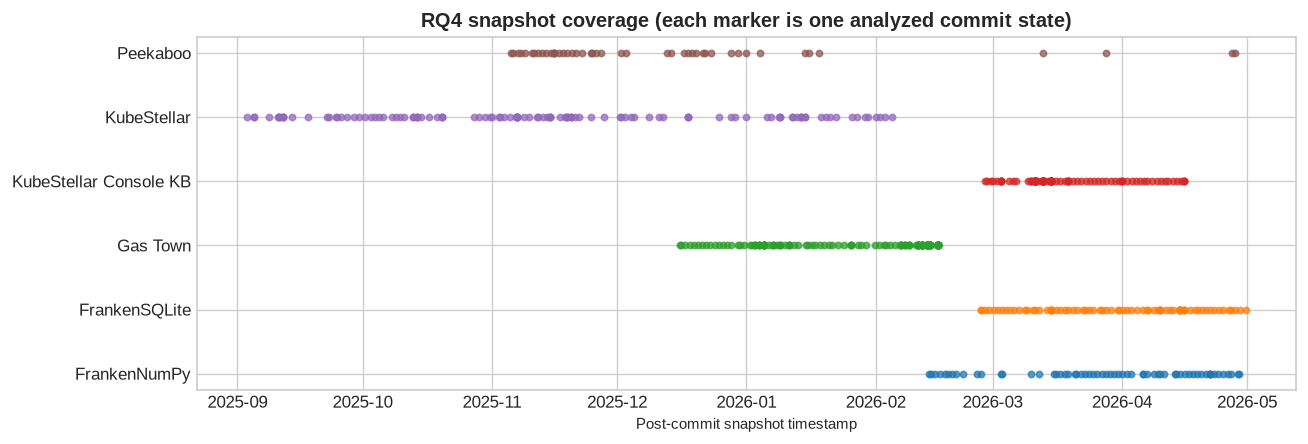

In [5]:
# Visualize coverage without implying that the cadence was uniform.
fig, ax = plt.subplots(figsize=(11, 3.8))
for y, (project, group) in enumerate(snapshots.groupby("project", sort=False)):
    ax.scatter(group["observed_at"], np.full(len(group), y), s=14, alpha=0.7)
ax.set_yticks(range(len(PROJECTS)), [PROJECTS[p]["display"] for p in PROJECTS])
ax.set_xlabel("Post-commit snapshot timestamp")
ax.set_title("RQ4 snapshot coverage (each marker is one analyzed commit state)")
plt.tight_layout()
plt.show()

### Six sheet exports per snapshot

| Export | Granularity | Available fields | Main use |
|---|---|---|---|
| Project summary | one row per metric (164 metrics) | size, complexity, comments, duplication, tests/coverage, Sonar issues/ratings/debt, git churn/scattering, coupling | longitudinal repository-level series |
| File metrics | one row per analyzed file | NCLOC, complexity, cognitive complexity, smells/bugs/vulnerabilities, duplication/comments, debt, churn/scattering, coupling | hotspots and concentration |
| Function size | one row per detected function/method | file, name, start/end line, size | size distributions and long-function tails |
| Issues | one row per exported Sonar issue | rule, language, severity, status, line, message, timestamps | issue composition when populated |
| Git scattering summary | one row per file/directory/project entity | scattering, commits analyzed, top coupled files | co-change breadth hotspots |
| Git scattering pairs | one row per entity–file pair | number of shared commits | temporal coupling hotspots |

The Excel sheets are named **Résumé Projet**, **Issues**, **Fichiers - Métriques**, **Git Scattering - Résumé**, **Git Scattering - Paires**, and **Function Size**. The CSV names are ASCII-normalized versions of those labels.

In [6]:
# Confirm that schemas are stable across all 562 exports of each kind.
schema_rows = []
for kind, suffix in ARTIFACT_SUFFIXES.items():
    variants = {}
    row_counts = []
    for project in PROJECTS:
        for path in (DATA_ROOT / project / "csv").glob(f"*_{suffix}"):
            with path.open(newline="", encoding="utf-8-sig") as handle:
                reader = csv.reader(handle)
                header = tuple(next(reader, []))
                count = sum(1 for _ in reader)
            variants[header] = variants.get(header, 0) + 1
            row_counts.append(count)
    schema_rows.append({
        "export": kind,
        "files": len(row_counts),
        "header_variants": len(variants),
        "columns": ", ".join(next(iter(variants))) if variants else "",
        "median_rows": np.median(row_counts),
        "max_rows": max(row_counts),
    })
schema_audit = pd.DataFrame(schema_rows).set_index("export")
schema_audit

,files,header_variants,columns,median_rows,max_rows
export,,,,,
project_summary,562,1,"metric, value",164.0,164
issues,562,1,"issue_key, file, rule, rule_source, severity, status, line, message, assignee, created_at, updat...",0.0,1442
file_metrics,562,1,"file, ncloc, complexity, cognitive_complexity, code_smells, bugs, vulnerabilities, duplicated_li...",732.0,2703
scattering_summary,562,1,"type, path, git_scattering, commits_analyzed, top_coupled_files",835.0,2461
scattering_pairs,562,1,"type, path, coupled_file, shared_commits",3468.0,12185
function_size,562,1,"file, function, start_line, end_line, size_lines",765.0,36613


### Metric interpretation

The most useful project-level measures are grouped below.

| Construct | Raw metrics | Recommended derived measure |
|---|---|---|
| System size | `ncloc`, `lines`, `files`, `functions`, `classes` | KLOC; functions per KLOC |
| Complexity | `complexity`, `cognitive_complexity` | complexity per KLOC to separate growth from density |
| Documentation | `comment_lines`, `comment_lines_density` | comment density (percentage points) |
| Duplication | `duplicated_lines`, `duplicated_lines_density` | duplicated-line density |
| Maintainability | `code_smells`, `sqale_index`, `sqale_debt_ratio`, ratings | smells and debt per KLOC |
| Reliability/security | `bugs`, `vulnerabilities`, `security_hotspots`, ratings | counts plus counts per KLOC |
| Tests | `tests`, `coverage`, `line_coverage`, failures/errors | only usable if the scanner imported test reports |
| Change history | `git_churn_commits`, `git_churn_lines` | churn lines per analyzed commit (a repository-history proxy) |
| Scattering/coupling | `git_scattering`, pairwise shared commits, efferent/afferent coupling | longitudinal proxy plus file-level hotspots |

`sqale_index` is treated as remediation effort (conventionally minutes in SonarQube), but the extraction code and exact unit are not documented here. Likewise, the precise formula/window behind `git_scattering` is not present in this repository; the observed tables are consistent with a co-change breadth measure. Both therefore remain descriptive proxies.

## 3. What can—and cannot—be answered from this extraction

**Supported now**

- Project growth and structural quality over post-commit snapshots.
- Complexity, documentation, duplication, maintainability, reliability, and security trends.
- Function-size distributions where the function extractor supports the project's languages.
- File-level hotspots, dependency coupling, git co-change scattering, and pairwise temporal coupling.
- Sonar issue-rule/severity composition where the detailed issue export is populated.

**Not supported by `data/rq4/` alone**

- Per-commit additions/deletions (patch size), files touched (breadth), or top-level directories touched (module breadth).
- A clean/dirty commit classification, test coupling for individual fixes, or Conventional Commit adherence.
- Agent-attributed versus unattributed comparisons.
- Commit volume in each inter-snapshot interval with a stable denominator.

Those require a keyed join to the repository's commit/file-detail and agent-detection datasets. The history metrics here are repository-state aggregates and must not be mislabeled as properties of the sampled commit.

## 4. Derived longitudinal measures and availability diagnostics

In [7]:
def safe_divide(numerator, denominator, multiplier=1.0):
    n = pd.to_numeric(numerator, errors="coerce")
    d = pd.to_numeric(denominator, errors="coerce")
    return (n / d.where(d > 0)) * multiplier

analysis = snapshots.copy()
analysis["kloc"] = pd.to_numeric(analysis["ncloc"], errors="coerce") / 1000
analysis["complexity_per_kloc"] = safe_divide(analysis["complexity"], analysis["ncloc"], 1000)
analysis["cognitive_per_kloc"] = safe_divide(analysis["cognitive_complexity"], analysis["ncloc"], 1000)
analysis["smells_per_kloc"] = safe_divide(analysis["code_smells"], analysis["ncloc"], 1000)
analysis["violations_per_kloc"] = safe_divide(analysis["violations"], analysis["ncloc"], 1000)
analysis["debt_minutes_per_kloc"] = safe_divide(analysis["sqale_index"], analysis["ncloc"], 1000)
analysis["functions_per_kloc"] = safe_divide(analysis["functions"], analysis["ncloc"], 1000)
analysis["churn_lines_per_commit"] = safe_divide(analysis["git_churn_lines"], analysis["git_churn_commits"])

def count_data_rows(path):
    with path.open(newline="", encoding="utf-8-sig") as handle:
        return max(sum(1 for _ in csv.reader(handle)) - 1, 0)

issue_counts = []
for _, row in analysis.iterrows():
    issue_counts.append(count_data_rows(artifact_path(row, "issues")))
analysis["detailed_issue_rows"] = issue_counts

availability = []
for project, group in analysis.groupby("project", sort=False):
    availability.append({
        "project": PROJECTS[project]["display"],
        "snapshots": len(group),
        "quality_gate_ERROR_%": 100 * (group["alert_status"] == "ERROR").mean(),
        "snapshots_with_test_count>0": int((pd.to_numeric(group["tests"], errors="coerce") > 0).sum()),
        "snapshots_with_coverage>0": int((pd.to_numeric(group["coverage"], errors="coerce") > 0).sum()),
        "snapshots_with_detailed_issues": int((group["detailed_issue_rows"] > 0).sum()),
        "latest_summary_violations": int(pd.to_numeric(group.iloc[-1]["violations"], errors="coerce")),
        "latest_detailed_issue_rows": int(group.iloc[-1]["detailed_issue_rows"]),
    })
availability = pd.DataFrame(availability).set_index("project")
availability

,snapshots,quality_gate_ERROR_%,snapshots_with_test_count>0,snapshots_with_coverage>0,snapshots_with_detailed_issues,latest_summary_violations,latest_detailed_issue_rows
project,,,,,,,
FrankenNumPy,61,93.442623,0,0,61,1672,1442
FrankenSQLite,75,98.666667,0,0,0,893,0
Gas Town,131,97.709924,0,0,0,1570,0
KubeStellar Console KB,132,33.333333,0,0,0,276,0
KubeStellar,117,17.094017,0,0,0,252,0
Peekaboo,46,78.260870,0,0,0,855,0


**Interpretation of the audit above.** A Sonar `alert_status=ERROR` is a failed quality gate, not a failed extraction. More importantly, every snapshot reports `tests=0` and `coverage=0`. Because these repositories can contain test files while the measurements remain zero, the defensible interpretation is that test-execution/coverage reports were not imported. Detailed `Issues.csv` rows are populated only for FrankenNumPy, despite nonzero summary issue counts elsewhere. Longitudinal issue totals remain usable from the summary; rule-level issue analysis does not.

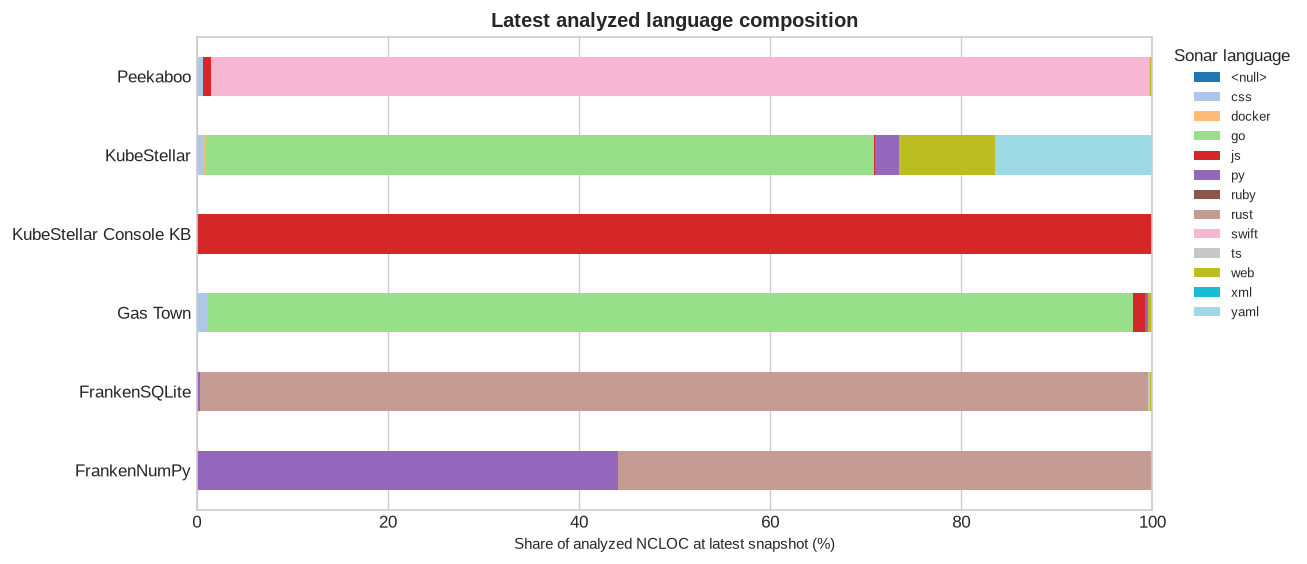

,observed_at,ncloc,files,functions,ncloc_language_distribution
display_name,,,,,
FrankenNumPy,2026-04-29 04:07:58,352293,2703,19681,css=69;py=155376;rust=196827;web=21
FrankenSQLite,2026-04-30 17:45:22,853373,1327,36391,css=135;js=1123;py=1942;rust=846319;ts=1857;web=1997
Gas Town,2026-02-15 23:23:48,184739,791,6663,<null>=25;css=2230;go=178667;js=2316;py=576;web=925
KubeStellar Console KB,2026-04-15 22:00:00,7228,1589,473,js=7228
KubeStellar,2026-02-04 23:00:00,24248,567,891,<null>=12;css=164;docker=27;go=16980;js=14;py=611;web=2449;yaml=3991
Peekaboo,2026-04-28 00:56:28,130558,1016,74,css=835;js=1096;ruby=37;swift=128095;ts=138;web=340;xml=17


In [8]:
def parse_language_distribution(value):
    if not isinstance(value, str) or "=" not in value:
        return {}
    result = {}
    for part in value.split(";"):
        if "=" not in part:
            continue
        language, count = part.split("=", 1)
        try:
            result[language] = float(count)
        except ValueError:
            pass
    return result

latest = analysis.groupby("project", sort=False).tail(1).copy()
language_rows = []
for _, row in latest.iterrows():
    distribution = parse_language_distribution(row["ncloc_language_distribution"])
    for language, ncloc in distribution.items():
        language_rows.append({
            "project": row["display_name"],
            "language": language,
            "ncloc": ncloc,
        })
languages = pd.DataFrame(language_rows)
lang_pivot = languages.pivot_table(index="project", columns="language", values="ncloc", aggfunc="sum", fill_value=0)
lang_share = lang_pivot.div(lang_pivot.sum(axis=1), axis=0) * 100
lang_share = lang_share.loc[[PROJECTS[p]["display"] for p in PROJECTS]]

ax = lang_share.plot(kind="barh", stacked=True, figsize=(11, 4.8), colormap="tab20")
ax.set_xlabel("Share of analyzed NCLOC at latest snapshot (%)")
ax.set_ylabel("")
ax.set_title("Latest analyzed language composition")
ax.legend(title="Sonar language", bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.show()

latest_context = latest[["display_name", "observed_at", "ncloc", "files", "functions", "ncloc_language_distribution"]].copy()
latest_context["ncloc"] = pd.to_numeric(latest_context["ncloc"], errors="coerce").astype("Int64")
latest_context["files"] = pd.to_numeric(latest_context["files"], errors="coerce").astype("Int64")
latest_context["functions"] = pd.to_numeric(latest_context["functions"], errors="coerce").astype("Int64")
latest_context.set_index("display_name")

## 5. Function-size extraction over time

Function sizes are aggregated snapshot-by-snapshot without retaining all function rows in memory. The Sonar `functions` count and the independent `Function Size` export are not guaranteed to share language coverage or parsing rules; their ratio is therefore an audit signal, not a recall estimate with known ground truth.

In [9]:
function_records = []
for project, group in analysis.groupby("project", sort=False):
    for _, row in group.iterrows():
        path = artifact_path(row, "function_size")
        sizes = pd.to_numeric(pd.read_csv(path, usecols=["size_lines"])["size_lines"], errors="coerce").dropna()
        if len(sizes):
            quantiles = sizes.quantile([0.50, 0.90, 0.95, 0.99])
            record = {
                "snapshot_id": row["snapshot_id"],
                "function_rows": len(sizes),
                "function_median": quantiles.loc[0.50],
                "function_p90": quantiles.loc[0.90],
                "function_p95": quantiles.loc[0.95],
                "function_p99": quantiles.loc[0.99],
                "function_max": sizes.max(),
                "function_share_gt_50": 100 * (sizes > 50).mean(),
                "function_share_gt_100": 100 * (sizes > 100).mean(),
                "function_share_gt_200": 100 * (sizes > 200).mean(),
            }
        else:
            record = {
                "snapshot_id": row["snapshot_id"],
                "function_rows": 0,
                "function_median": np.nan,
                "function_p90": np.nan,
                "function_p95": np.nan,
                "function_p99": np.nan,
                "function_max": np.nan,
                "function_share_gt_50": np.nan,
                "function_share_gt_100": np.nan,
                "function_share_gt_200": np.nan,
            }
        function_records.append(record)
    print(f"Aggregated {len(group):3d} function-size snapshots for {PROJECTS[project]['display']}")

function_temporal = pd.DataFrame(function_records)
analysis = analysis.merge(function_temporal, on="snapshot_id", how="left")
analysis["function_export_to_sonar_ratio"] = safe_divide(analysis["function_rows"], analysis["functions"])
analysis.groupby("display_name", sort=False).tail(1)[
    ["display_name", "functions", "function_rows", "function_export_to_sonar_ratio",
     "function_median", "function_p95", "function_max", "function_share_gt_100"]
].set_index("display_name")

Aggregated  61 function-size snapshots for FrankenNumPy


Aggregated  75 function-size snapshots for FrankenSQLite


Aggregated 131 function-size snapshots for Gas Town
Aggregated 132 function-size snapshots for KubeStellar Console KB
Aggregated 117 function-size snapshots for KubeStellar
Aggregated  46 function-size snapshots for Peekaboo


,functions,function_rows,function_export_to_sonar_ratio,function_median,function_p95,function_max,function_share_gt_100
display_name,,,,,,,
FrankenNumPy,19681.0,20372,1.035110,9.0,69.0,2289.0,2.577067
FrankenSQLite,36391.0,36613,1.006100,14.0,67.0,4619.0,2.253298
Gas Town,6663.0,6413,0.962479,21.0,87.0,728.0,3.446125
KubeStellar Console KB,473.0,0,0.000000,NaN,NaN,NaN,NaN
KubeStellar,891.0,767,0.860831,8.0,49.7,300.0,1.694915
Peekaboo,74.0,33,0.445946,25.0,89.4,132.0,6.060606


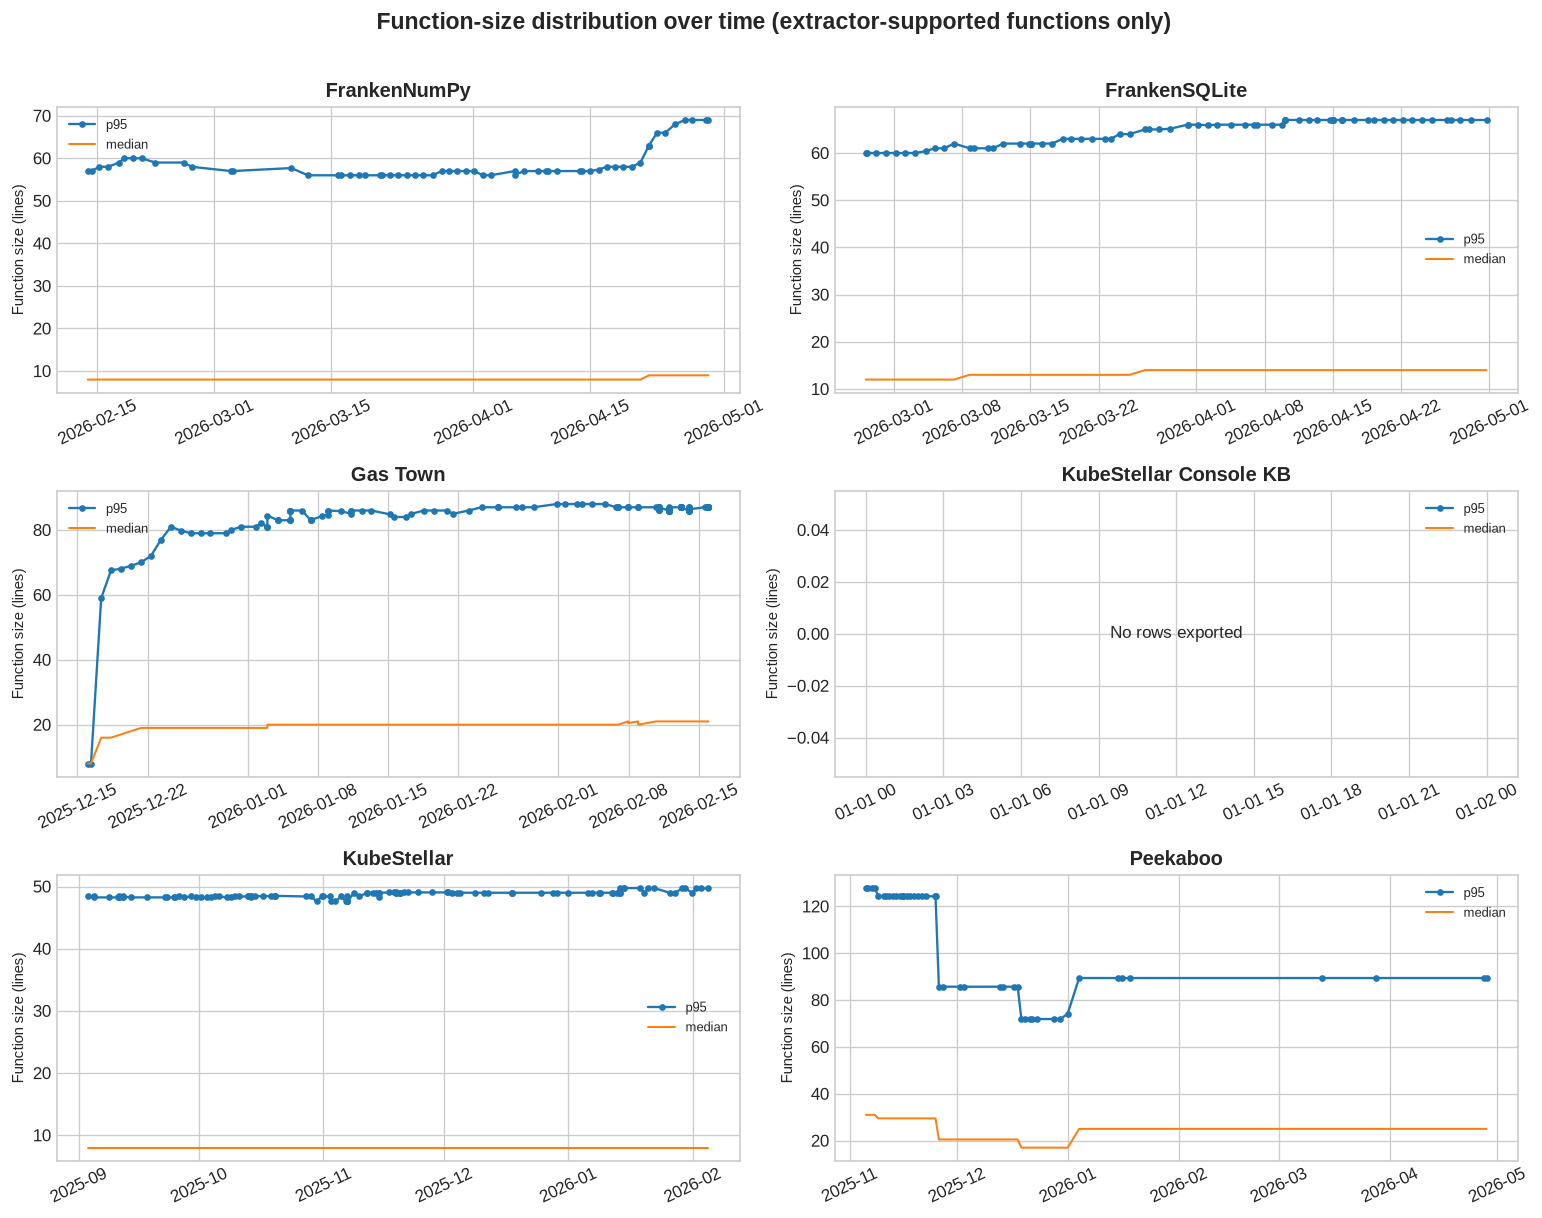

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(13, 10), sharex=False)
for ax, (project, group) in zip(axes.flat, analysis.groupby("project", sort=False)):
    ax.plot(group["observed_at"], group["function_p95"], marker=".", lw=1.4, label="p95")
    ax.plot(group["observed_at"], group["function_median"], lw=1.2, label="median")
    ax.set_title(PROJECTS[project]["display"])
    ax.set_ylabel("Function size (lines)")
    ax.tick_params(axis="x", rotation=25)
    if group["function_rows"].max() == 0:
        ax.text(0.5, 0.5, "No rows exported", ha="center", va="center", transform=ax.transAxes)
    ax.legend()
fig.suptitle("Function-size distribution over time (extractor-supported functions only)", y=1.01, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 6. Independent longitudinal analysis by project

Each project gets the same six views so changes are comparable *within that repository*:

1. growth in analyzed NCLOC and files;
2. cyclomatic and cognitive complexity density;
3. comment and duplication density;
4. normalized Sonar violations and remediation effort;
5. repository-history co-change/churn proxies;
6. dependency coupling counts.

Normalization by KLOC avoids treating growth alone as quality degradation. Endpoint changes and rank correlations are descriptive—not causal tests—and snapshots are serially dependent.

### FrankenNumPy

A clean-room, memory-safe Rust reimplementation of NumPy with Python compatibility/conformance assets.

- Observation window: **2026-02-13 to 2026-04-29** (61 snapshots; 59 unique dates).
- Size: **160,635 NCLOC → 352,293 NCLOC (+119.3%)**; files: **2,292 → 2,703 (+17.9%)**.
- Complexity density: **147.5/KLOC → 144.5/KLOC (-2.0%)** (time-rank ρ=0.04); cognitive density: **128.8/KLOC → 114.8/KLOC (-10.8%)**.
- Comment density: **31.2% → 17.9% (-42.6%)** (time-rank ρ=-1.00); duplication: **0.6% → 2.0% (+233.3%)**.
- Static-analysis burden: **8.8/KLOC → 4.7/KLOC (-45.9%)**; quality gate was ERROR in **93.4%** of snapshots.
- Function-size p95: **57.0 lines → 69.0 lines (+21.1%)**. This is conditional on extractor language coverage.
- Git scattering: **0.0 → 11.7 (from a zero baseline)**. This is a repository-history co-change proxy, not sampled-commit breadth.
- Test/coverage values are uninformative (all zero); do not infer that the repository has no tests.

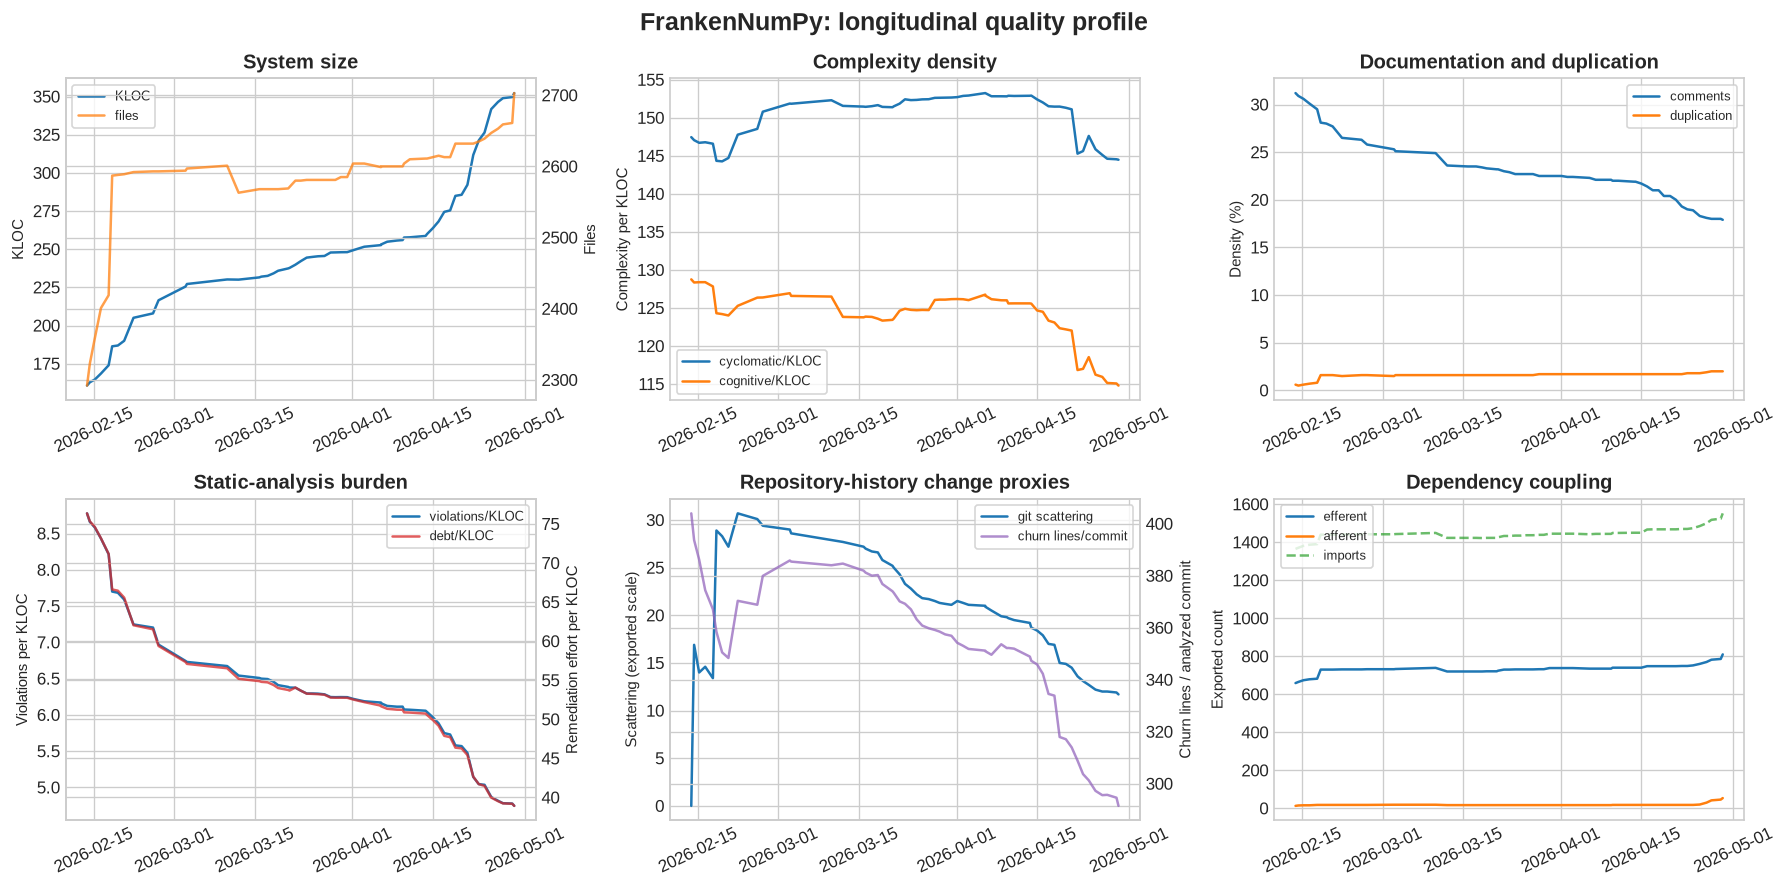

### FrankenSQLite

A ground-up Rust reimplementation of SQLite emphasizing compatibility, concurrent writers, and durability.

- Observation window: **2026-02-26 to 2026-04-30** (75 snapshots; 65 unique dates).
- Size: **441,502 NCLOC → 853,373 NCLOC (+93.3%)**; files: **927 → 1,327 (+43.1%)**.
- Complexity density: **131.9/KLOC → 128.8/KLOC (-2.3%)** (time-rank ρ=-0.90); cognitive density: **82.4/KLOC → 89.3/KLOC (+8.4%)**.
- Comment density: **9.4% → 8.0% (-14.9%)** (time-rank ρ=-0.89); duplication: **5.7% → 7.6% (+33.3%)**.
- Static-analysis burden: **1.1/KLOC → 1.0/KLOC (-8.9%)**; quality gate was ERROR in **98.7%** of snapshots.
- Function-size p95: **60.0 lines → 67.0 lines (+11.7%)**. This is conditional on extractor language coverage.
- Git scattering: **0.0 → 8.4 (from a zero baseline)**. This is a repository-history co-change proxy, not sampled-commit breadth.
- Test/coverage values are uninformative (all zero); do not infer that the repository has no tests.
- Detailed issue rows are absent; rule/severity analysis is unavailable even though summary violations may be nonzero.

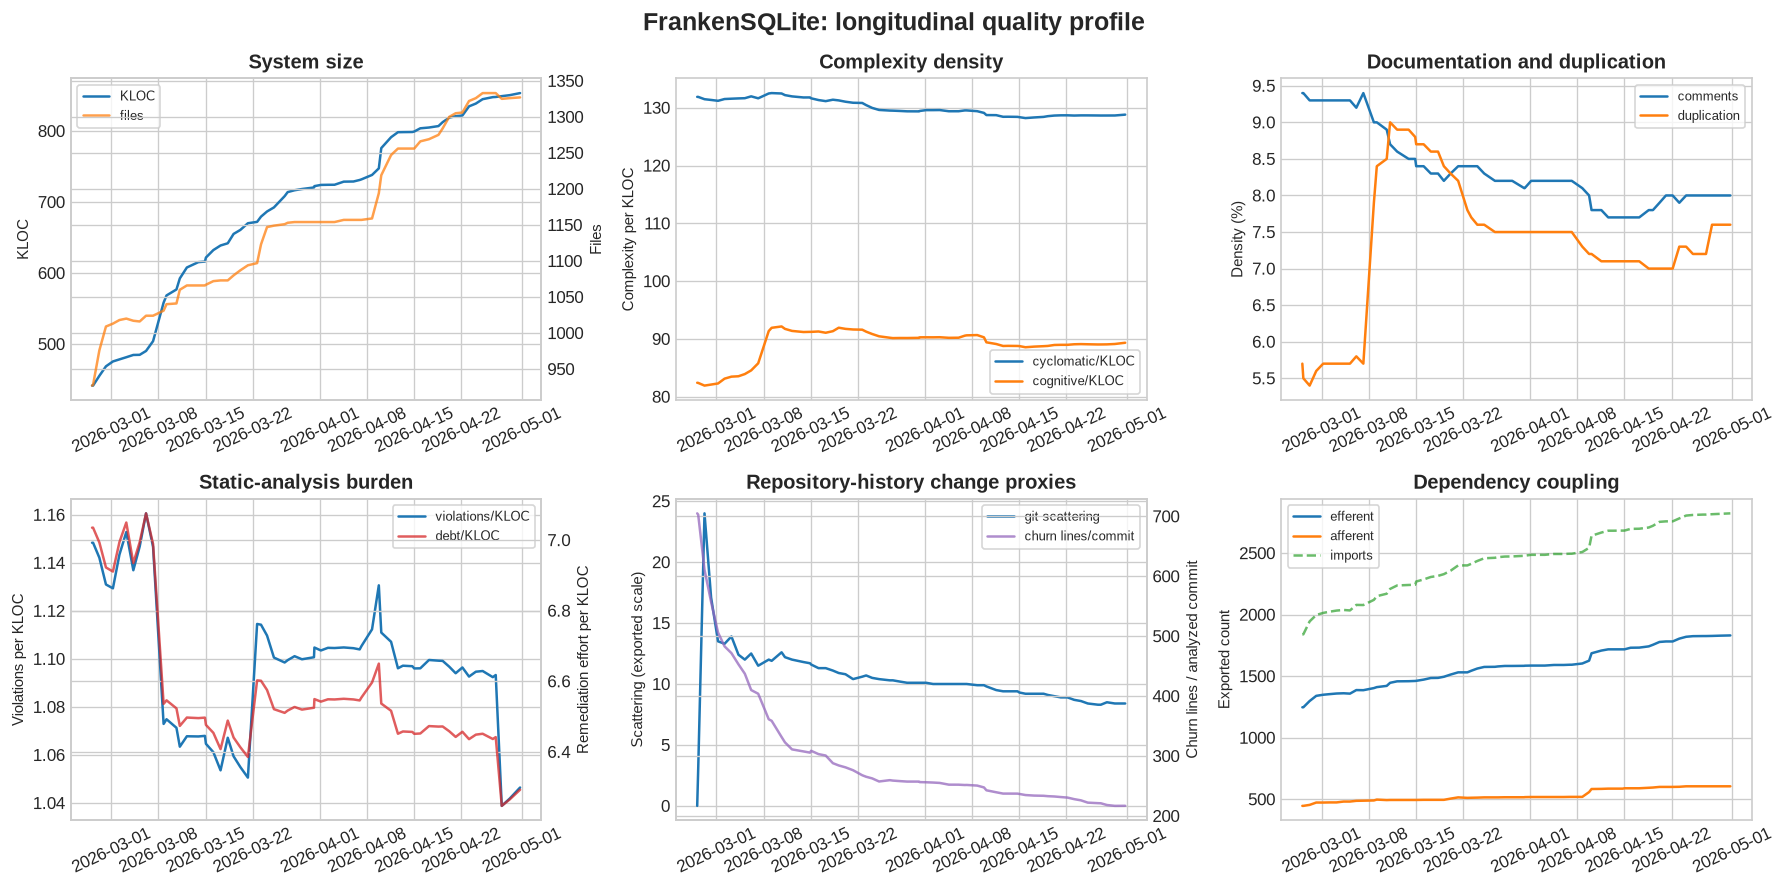

### Gas Town

A Go workspace manager for coordinating multiple AI coding agents with persistent, git-backed work tracking.

- Observation window: **2025-12-16 to 2026-02-15** (131 snapshots; 62 unique dates).
- Size: **13 NCLOC → 184,739 NCLOC (+1420969.2%)**; files: **5 → 791 (+15720.0%)**.
- Complexity density: **153.8/KLOC → 193.9/KLOC (+26.0%)** (time-rank ρ=0.65); cognitive density: **76.9/KLOC → 222.2/KLOC (+188.9%)**.
- Comment density: **0.0% → 13.5% (from a zero baseline)** (time-rank ρ=0.01); duplication: **0.0% → 5.0% (from a zero baseline)**.
- Static-analysis burden: **0.0/KLOC → 8.5/KLOC (from a zero baseline)**; quality gate was ERROR in **97.7%** of snapshots.
- Function-size p95: **8.0 lines → 87.0 lines (+987.5%)**. This is conditional on extractor language coverage.
- Git scattering: **0.0 → 15.2 (from a zero baseline)**. This is a repository-history co-change proxy, not sampled-commit breadth.
- Test/coverage values are uninformative (all zero); do not infer that the repository has no tests.
- Detailed issue rows are absent; rule/severity analysis is unavailable even though summary violations may be nonzero.

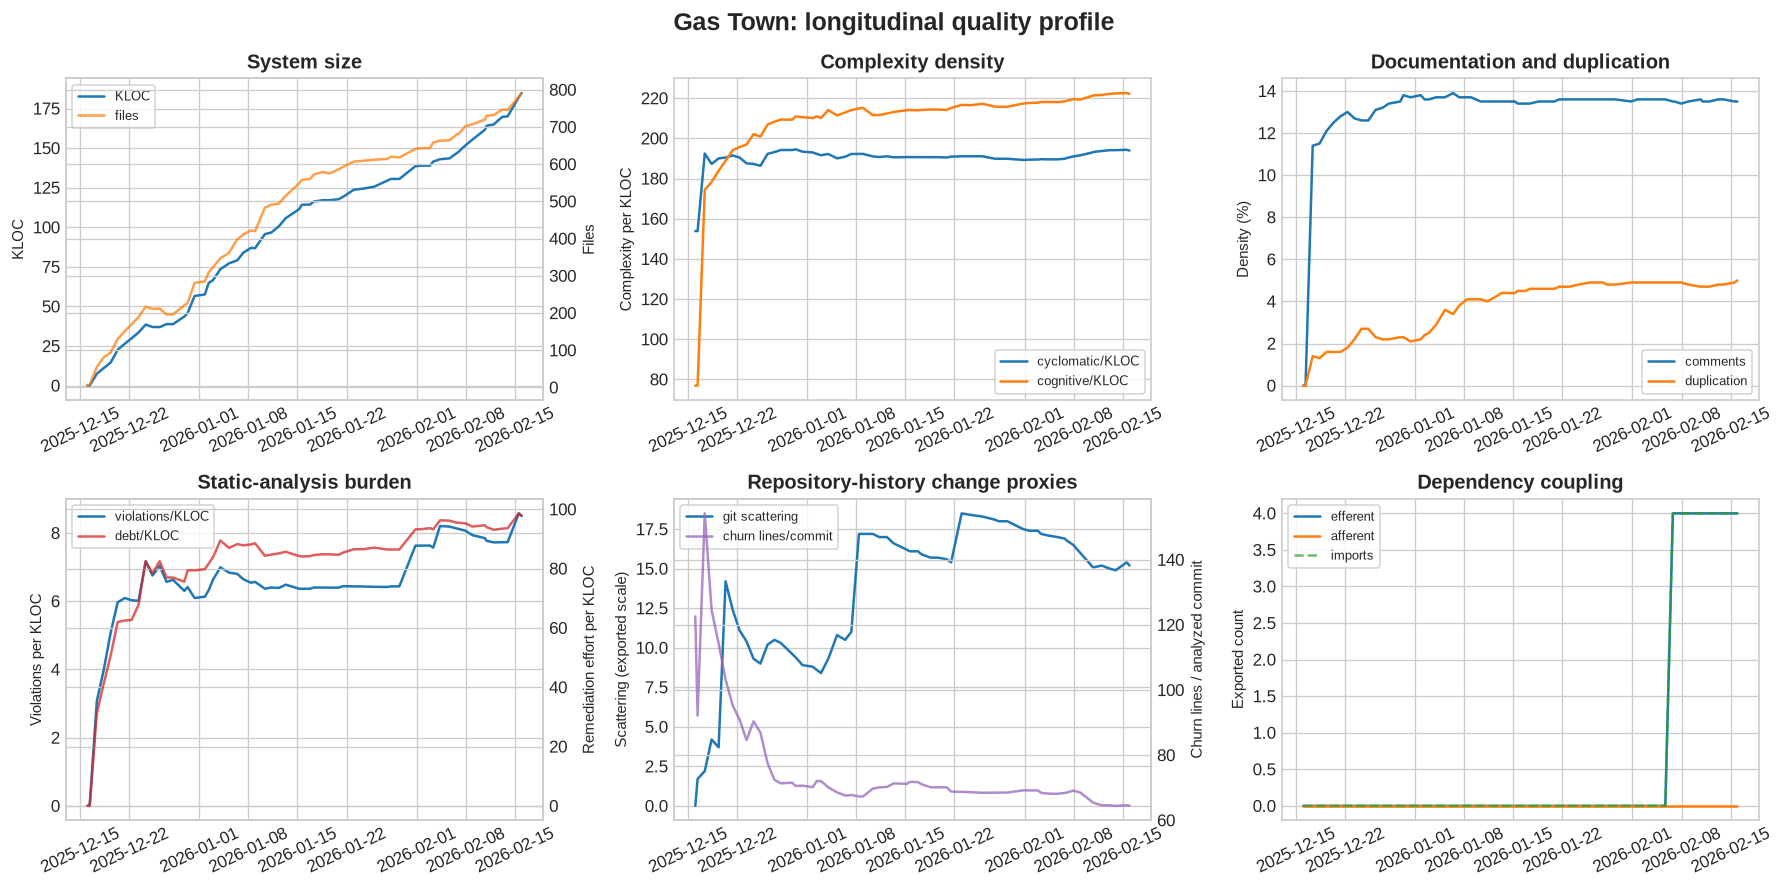

### KubeStellar Console KB

A community knowledge base of reusable AI-mission fixes and Kubernetes operational runbooks.

- Observation window: **2026-02-27 to 2026-04-15** (132 snapshots; 48 unique dates).
- Size: **0 NCLOC → 7,228 NCLOC (from a zero baseline)**; files: **4 → 1,589 (+39625.0%)**.
- Complexity density: **211.2/KLOC → 278.2/KLOC (+31.8%)** (time-rank ρ=0.40); cognitive density: **197.2/KLOC → 235.6/KLOC (+19.5%)**.
- Comment density: **0.0% → 9.8% (from a zero baseline)** (time-rank ρ=0.96); duplication: **0.0% → 0.6% (from a zero baseline)**.
- Static-analysis burden: **47.8/KLOC → 38.2/KLOC (-20.1%)**; quality gate was ERROR in **33.3%** of snapshots.
- Function-size p95: **not available**. This is conditional on extractor language coverage.
- Git scattering: **0.0 → 1,751.5 (from a zero baseline)**. This is a repository-history co-change proxy, not sampled-commit breadth.
- Test/coverage values are uninformative (all zero); do not infer that the repository has no tests.
- Detailed issue rows are absent; rule/severity analysis is unavailable even though summary violations may be nonzero.

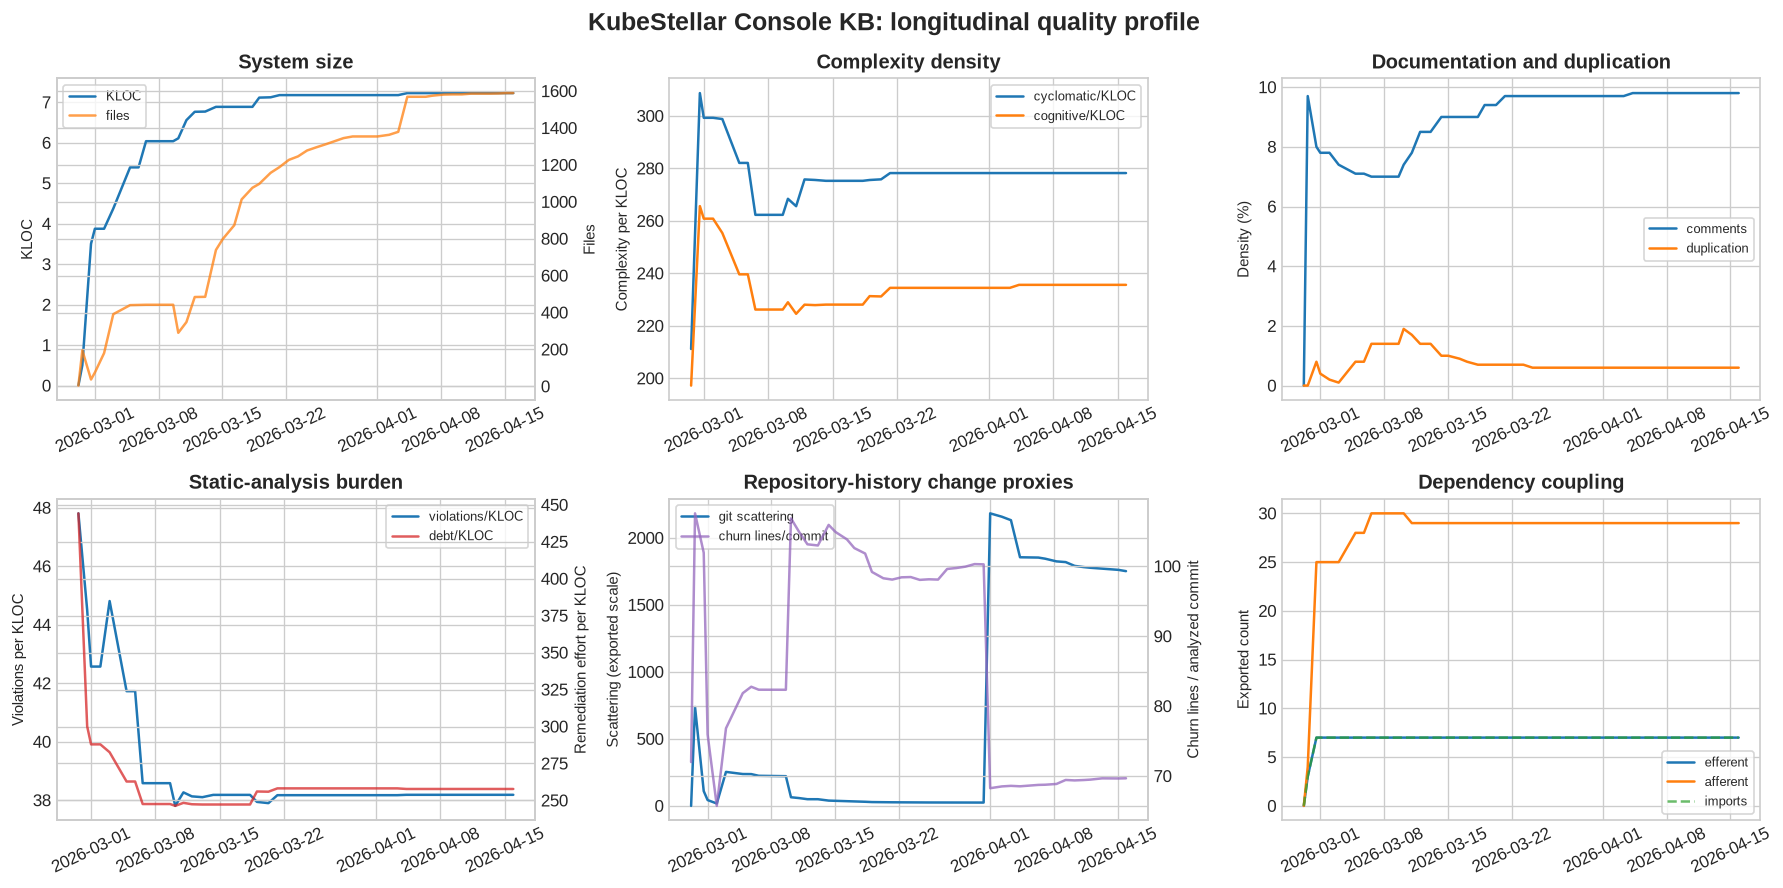

### KubeStellar

A CNCF Sandbox project for multi-cluster Kubernetes configuration and workload orchestration.

- Observation window: **2025-09-03 to 2026-02-04** (117 snapshots; 99 unique dates).
- Size: **23,103 NCLOC → 24,248 NCLOC (+5.0%)**; files: **495 → 567 (+14.5%)**.
- Complexity density: **124.1/KLOC → 125.8/KLOC (+1.3%)** (time-rank ρ=0.85); cognitive density: **141.4/KLOC → 145.6/KLOC (+3.0%)**.
- Comment density: **15.0% → 14.9% (-0.7%)** (time-rank ρ=-0.74); duplication: **0.2% → 0.1% (-50.0%)**.
- Static-analysis burden: **10.3/KLOC → 10.4/KLOC (+0.9%)**; quality gate was ERROR in **17.1%** of snapshots.
- Function-size p95: **48.4 lines → 49.7 lines (+2.7%)**. This is conditional on extractor language coverage.
- Git scattering: **30.5 → 39.7 (+30.2%)**. This is a repository-history co-change proxy, not sampled-commit breadth.
- Test/coverage values are uninformative (all zero); do not infer that the repository has no tests.
- Detailed issue rows are absent; rule/severity analysis is unavailable even though summary violations may be nonzero.

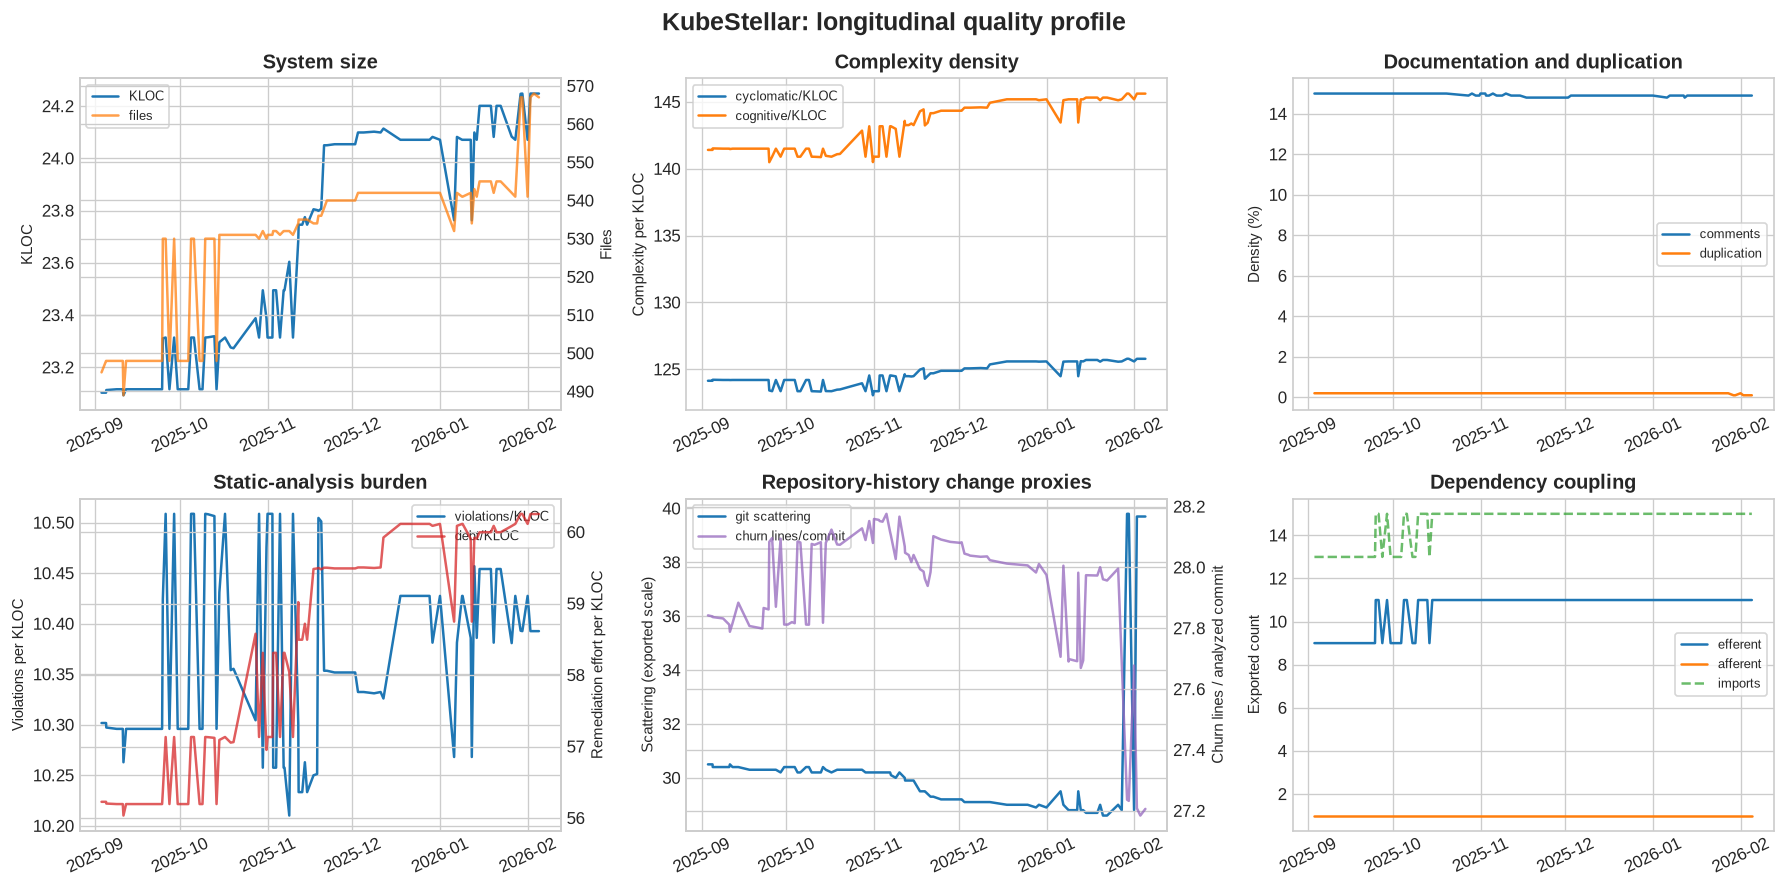

### Peekaboo

A macOS CLI/app and MCP server for screen capture, accessibility inspection, and native UI automation.

- Observation window: **2025-11-05 to 2026-04-28** (46 snapshots; 44 unique dates).
- Size: **95,842 NCLOC → 130,558 NCLOC (+36.2%)**; files: **740 → 1,016 (+37.3%)**.
- Complexity density: **1.9/KLOC → 2.4/KLOC (+23.9%)** (time-rank ρ=-0.13); cognitive density: **2.0/KLOC → 2.6/KLOC (+26.2%)**.
- Comment density: **13.7% → 7.5% (-45.3%)** (time-rank ρ=-0.99); duplication: **0.0% → 0.0% (from a zero baseline)**.
- Static-analysis burden: **16.4/KLOC → 6.5/KLOC (-60.0%)**; quality gate was ERROR in **78.3%** of snapshots.
- Function-size p95: **127.8 lines → 89.4 lines (-30.0%)**. This is conditional on extractor language coverage.
- Git scattering: **117.6 → 59.4 (-49.5%)**. This is a repository-history co-change proxy, not sampled-commit breadth.
- Test/coverage values are uninformative (all zero); do not infer that the repository has no tests.
- Detailed issue rows are absent; rule/severity analysis is unavailable even though summary violations may be nonzero.

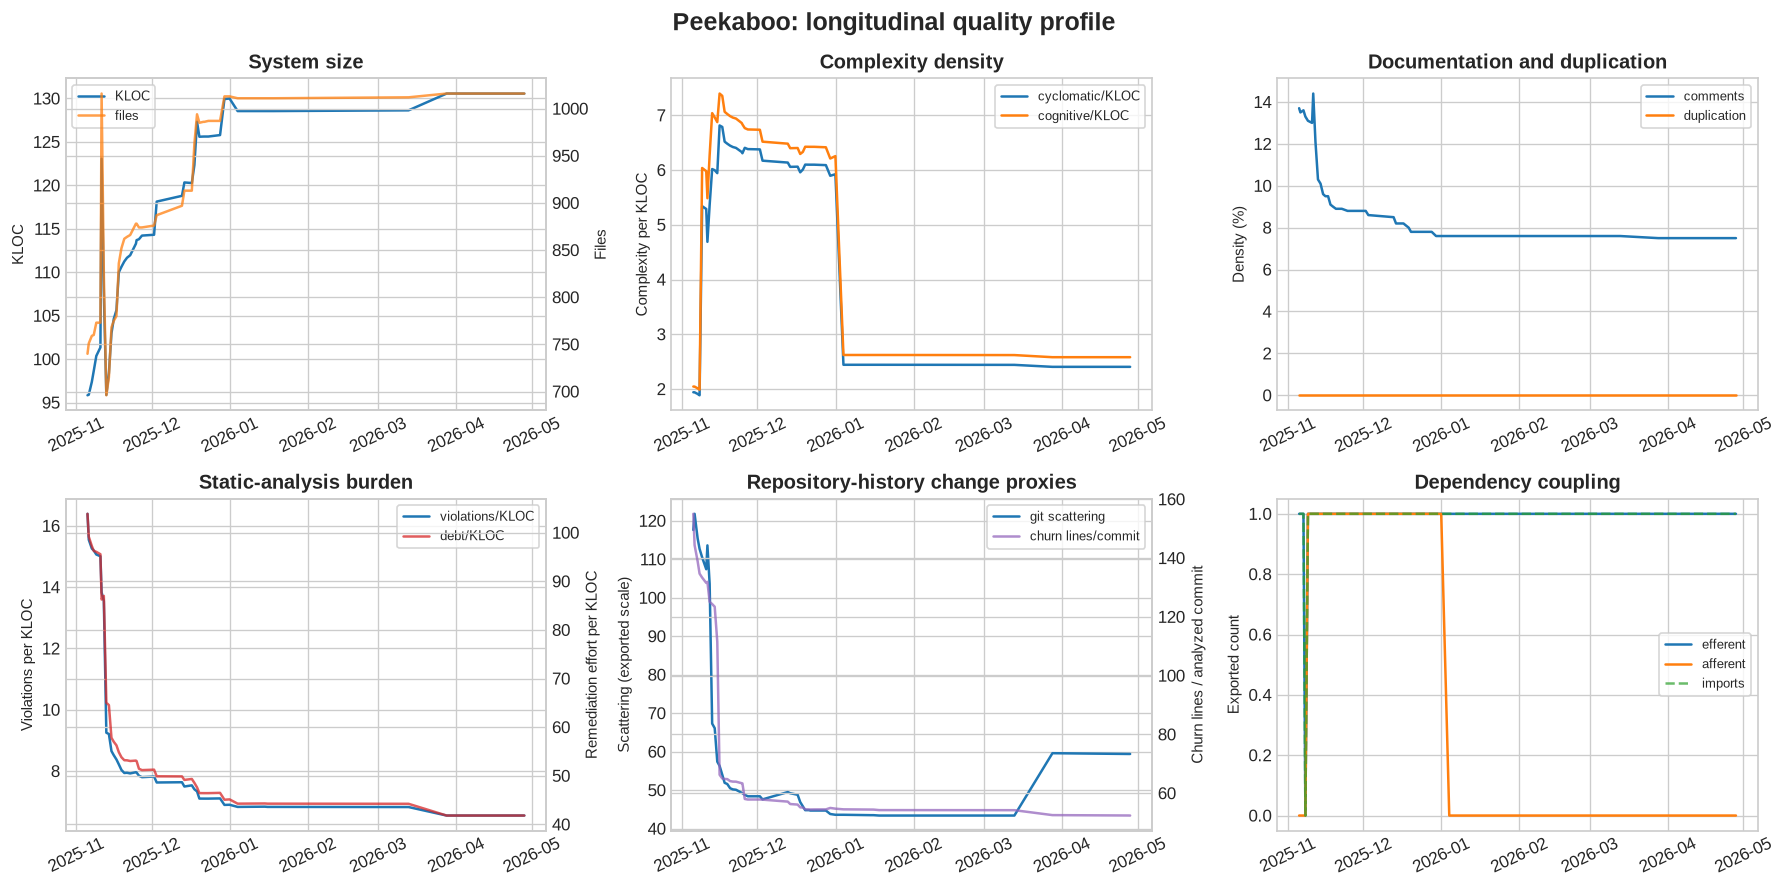

In [11]:
def combined_legend(ax, ax2=None, loc="best"):
    handles, labels = ax.get_legend_handles_labels()
    if ax2 is not None:
        h2, l2 = ax2.get_legend_handles_labels()
        handles += h2
        labels += l2
    if handles:
        ax.legend(handles, labels, loc=loc, frameon=True)

def endpoint_change(group, metric):
    series = pd.to_numeric(group[metric], errors="coerce").dropna()
    if len(series) < 2:
        return np.nan, np.nan, np.nan
    first, last = series.iloc[0], series.iloc[-1]
    pct = np.nan if first == 0 else 100 * (last - first) / abs(first)
    return first, last, pct

def spearman_time(group, metric):
    y = pd.to_numeric(group[metric], errors="coerce")
    x = group["observed_at"].rank()
    return x.corr(y.rank()) if y.notna().sum() >= 3 and y.nunique() > 1 else np.nan

def fmt_delta(group, metric, unit="", digits=1):
    first, last, pct = endpoint_change(group, metric)
    if pd.isna(first) or pd.isna(last):
        return "not available"
    change = f"{pct:+.1f}%" if pd.notna(pct) else "from a zero baseline"
    return f"{first:,.{digits}f}{unit} → {last:,.{digits}f}{unit} ({change})"

def plot_project(group, project):
    x = group["observed_at"]
    fig, axes = plt.subplots(2, 3, figsize=(15, 7.5))
    
    ax = axes[0, 0]
    ax.plot(x, group["kloc"], color="#1f77b4", label="KLOC")
    ax2 = ax.twinx()
    ax2.plot(x, pd.to_numeric(group["files"], errors="coerce"), color="#ff7f0e", alpha=.75, label="files")
    ax.set_title("System size")
    ax.set_ylabel("KLOC")
    ax2.set_ylabel("Files")
    combined_legend(ax, ax2, "upper left")
    
    ax = axes[0, 1]
    ax.plot(x, group["complexity_per_kloc"], label="cyclomatic/KLOC")
    ax.plot(x, group["cognitive_per_kloc"], label="cognitive/KLOC")
    ax.set_title("Complexity density")
    ax.set_ylabel("Complexity per KLOC")
    combined_legend(ax)
    
    ax = axes[0, 2]
    ax.plot(x, pd.to_numeric(group["comment_lines_density"], errors="coerce"), label="comments")
    ax.plot(x, pd.to_numeric(group["duplicated_lines_density"], errors="coerce"), label="duplication")
    ax.set_title("Documentation and duplication")
    ax.set_ylabel("Density (%)")
    combined_legend(ax)
    
    ax = axes[1, 0]
    ax.plot(x, group["violations_per_kloc"], label="violations/KLOC")
    ax2 = ax.twinx()
    ax2.plot(x, group["debt_minutes_per_kloc"], color="#d62728", alpha=.75, label="debt/KLOC")
    ax.set_title("Static-analysis burden")
    ax.set_ylabel("Violations per KLOC")
    ax2.set_ylabel("Remediation effort per KLOC")
    combined_legend(ax, ax2)
    
    ax = axes[1, 1]
    ax.plot(x, pd.to_numeric(group["git_scattering"], errors="coerce"), label="git scattering")
    ax2 = ax.twinx()
    ax2.plot(x, group["churn_lines_per_commit"], color="#9467bd", alpha=.75, label="churn lines/commit")
    ax.set_title("Repository-history change proxies")
    ax.set_ylabel("Scattering (exported scale)")
    ax2.set_ylabel("Churn lines / analyzed commit")
    combined_legend(ax, ax2)
    
    ax = axes[1, 2]
    ax.plot(x, pd.to_numeric(group["coupling_efferent"], errors="coerce"), label="efferent")
    ax.plot(x, pd.to_numeric(group["ca_afferent_coupling"], errors="coerce"), label="afferent")
    ax.plot(x, pd.to_numeric(group["coupling_imports"], errors="coerce"), ls="--", alpha=.7, label="imports")
    ax.set_title("Dependency coupling")
    ax.set_ylabel("Exported count")
    combined_legend(ax)
    
    for ax in axes.flat:
        ax.tick_params(axis="x", rotation=25)
    fig.suptitle(f"{PROJECTS[project]['display']}: longitudinal quality profile", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()

for project, group in analysis.groupby("project", sort=False):
    gate_error = 100 * (group["alert_status"] == "ERROR").mean()
    rho_density = spearman_time(group, "complexity_per_kloc")
    rho_comment = spearman_time(group, "comment_lines_density")
    lines = [
        f"### {PROJECTS[project]['display']}",
        "",
        PROJECTS[project]["description"],
        "",
        f"- Observation window: **{group['observed_at'].min().date()} to {group['observed_at'].max().date()}** "
        f"({len(group)} snapshots; {group['filename_date'].dt.date.nunique()} unique dates).",
        f"- Size: **{fmt_delta(group, 'ncloc', ' NCLOC', 0)}**; files: **{fmt_delta(group, 'files', '', 0)}**.",
        f"- Complexity density: **{fmt_delta(group, 'complexity_per_kloc', '/KLOC')}** "
        f"(time-rank ρ={rho_density:.2f}); cognitive density: **{fmt_delta(group, 'cognitive_per_kloc', '/KLOC')}**.",
        f"- Comment density: **{fmt_delta(group, 'comment_lines_density', '%')}** "
        f"(time-rank ρ={rho_comment:.2f}); duplication: **{fmt_delta(group, 'duplicated_lines_density', '%')}**.",
        f"- Static-analysis burden: **{fmt_delta(group, 'violations_per_kloc', '/KLOC')}**; "
        f"quality gate was ERROR in **{gate_error:.1f}%** of snapshots.",
        f"- Function-size p95: **{fmt_delta(group, 'function_p95', ' lines')}**. "
        f"This is conditional on extractor language coverage.",
        f"- Git scattering: **{fmt_delta(group, 'git_scattering')}**. This is a repository-history co-change proxy, not sampled-commit breadth.",
    ]
    if (pd.to_numeric(group["tests"], errors="coerce") == 0).all():
        lines.append("- Test/coverage values are uninformative (all zero); do not infer that the repository has no tests.")
    if (group["detailed_issue_rows"] == 0).all():
        lines.append("- Detailed issue rows are absent; rule/severity analysis is unavailable even though summary violations may be nonzero.")
    display(Markdown("\n".join(lines)))
    plot_project(group, project)

## 7. Endpoint and trend synopsis

This compact table is a navigation aid for the six independent profiles. Endpoint deltas use the first and last sampled states; Spearman ρ uses all snapshots and captures monotonic direction without assuming linearity. Large early-stage percentage changes should be read alongside the plots.

In [12]:
trend_rows = []
trend_metrics = {
    "ncloc": "NCLOC",
    "complexity_per_kloc": "Complexity/KLOC",
    "cognitive_per_kloc": "Cognitive/KLOC",
    "comment_lines_density": "Comment density",
    "duplicated_lines_density": "Duplication density",
    "violations_per_kloc": "Violations/KLOC",
    "debt_minutes_per_kloc": "Debt/KLOC",
    "function_p95": "Function p95",
    "git_scattering": "Git scattering",
}
for project, group in analysis.groupby("project", sort=False):
    row = {"project": PROJECTS[project]["display"]}
    for metric, label in trend_metrics.items():
        first, last, pct = endpoint_change(group, metric)
        row[f"{label} Δ%"] = pct
        row[f"{label} ρ"] = spearman_time(group, metric)
    trend_rows.append(row)
trend_table = pd.DataFrame(trend_rows).set_index("project")
trend_table.style.format("{:+.2f}", na_rep="—").background_gradient(cmap="RdYlGn_r", subset=[
    "Complexity/KLOC Δ%", "Cognitive/KLOC Δ%", "Duplication density Δ%",
    "Violations/KLOC Δ%", "Debt/KLOC Δ%", "Function p95 Δ%"
])

,NCLOC Δ%,NCLOC ρ,Complexity/KLOC Δ%,Complexity/KLOC ρ,Cognitive/KLOC Δ%,Cognitive/KLOC ρ,Comment density Δ%,Comment density ρ,Duplication density Δ%,Duplication density ρ,Violations/KLOC Δ%,Violations/KLOC ρ,Debt/KLOC Δ%,Debt/KLOC ρ,Function p95 Δ%,Function p95 ρ,Git scattering Δ%,Git scattering ρ
project,,,,,,,,,,,,,,,,,,
FrankenNumPy,+119.31,+1.00,-2.01,+0.04,-10.85,-0.63,-42.63,-1.00,+233.33,+0.93,-45.93,-1.00,-49.02,-1.00,+21.05,+0.39,—,-0.66
FrankenSQLite,+93.29,+1.00,-2.33,-0.90,+8.40,-0.15,-14.89,-0.89,+33.33,-0.11,-8.88,-0.31,-10.55,-0.67,+11.67,+0.97,—,-0.84
Gas Town,+1420969.23,+1.00,+26.03,+0.65,+188.85,+0.97,—,+0.01,—,+0.85,—,+0.81,—,+0.85,+987.50,+0.76,—,+0.33
KubeStellar Console KB,—,+1.00,+31.76,+0.40,+19.47,+0.51,—,+0.96,—,-0.54,-20.13,-0.29,-41.98,+0.20,—,—,—,-0.13
KubeStellar,+4.96,+0.95,+1.32,+0.85,+2.98,+0.88,-0.67,-0.74,-50.00,-0.35,+0.88,+0.28,+7.16,+0.95,+2.69,+0.80,+30.16,-0.72
Peekaboo,+36.22,+0.95,+23.93,-0.13,+26.22,-0.25,-45.26,-0.99,—,—,-60.05,-1.00,-59.74,-1.00,-30.05,-0.76,-49.49,-0.77


## 8. File/function hotspots and artifact sensitivity

Raw history metrics can be dominated by paths that do not represent maintained first-party source: vendored code, clean-room reference trees, generated mission corpora, checked-in build outputs, or bulk evidence artifacts. The classifier below is intentionally transparent and conservative. It does not discard data from the main time series; it quantifies sensitivity and supplies source-like hotspot views.

For `console-kb`, generated JSON is also the product itself, so a “generated” label is not a judgment of irrelevance. For `franken_numpy`, `legacy_numpy_code` is a reference implementation. For KubeStellar and Peekaboo, `vendor/` and `.build/` can strongly inflate co-change statistics.

In [13]:
ARTIFACT_PATTERN = re.compile(
    r"(^|/)(vendor|node_modules|\.build|target|dist|build|coverage|third_party|"
    r"legacy_numpy_code|artifacts|generated|cncf-generated)(/|$)",
    flags=re.IGNORECASE,
)

def is_artifact_like(path):
    return bool(ARTIFACT_PATTERN.search(str(path)))

def read_latest_artifact(project, kind):
    row = analysis[analysis["project"] == project].iloc[-1]
    return pd.read_csv(artifact_path(row, kind))

sensitivity_rows = []
latest_tables = {}
for project in PROJECTS:
    row = analysis[analysis["project"] == project].iloc[-1]
    files = read_latest_artifact(project, "file_metrics")
    functions = read_latest_artifact(project, "function_size")
    scatter = read_latest_artifact(project, "scattering_summary")
    pairs = read_latest_artifact(project, "scattering_pairs")
    issues = read_latest_artifact(project, "issues")
    
    for column in files.columns.drop("file"):
        files[column] = pd.to_numeric(files[column], errors="coerce")
    files["artifact_like"] = files["file"].map(is_artifact_like)
    scatter["git_scattering"] = pd.to_numeric(scatter["git_scattering"], errors="coerce")
    scatter["artifact_like"] = scatter["path"].map(is_artifact_like)
    if len(functions):
        functions["size_lines"] = pd.to_numeric(functions["size_lines"], errors="coerce")
        functions["artifact_like"] = functions["file"].map(is_artifact_like)
    
    latest_tables[project] = {
        "files": files,
        "functions": functions,
        "scatter": scatter,
        "pairs": pairs,
        "issues": issues,
    }
    total_file_ncloc = files["ncloc"].sum()
    top10_ncloc = files.nlargest(10, "ncloc")["ncloc"].sum()
    top20_scatter = scatter.nlargest(20, "git_scattering")
    sensitivity_rows.append({
        "project": PROJECTS[project]["display"],
        "file_metric_rows": len(files),
        "file_NCLOC / summary_NCLOC": total_file_ncloc / float(row["ncloc"]) if float(row["ncloc"]) else np.nan,
        "artifact-like share of file NCLOC": files.loc[files["artifact_like"], "ncloc"].sum() / total_file_ncloc if total_file_ncloc else np.nan,
        "top-10 file share of NCLOC": top10_ncloc / total_file_ncloc if total_file_ncloc else np.nan,
        "function_rows": len(functions),
        "function export / Sonar functions": len(functions) / float(row["functions"]) if float(row["functions"]) else np.nan,
        "artifact-like among top-20 scattering": top20_scatter["artifact_like"].mean() if len(top20_scatter) else np.nan,
        "detailed_issue_rows": len(issues),
    })

sensitivity = pd.DataFrame(sensitivity_rows).set_index("project")
sensitivity.style.format({
    "file_NCLOC / summary_NCLOC": "{:.1%}",
    "artifact-like share of file NCLOC": "{:.1%}",
    "top-10 file share of NCLOC": "{:.1%}",
    "function export / Sonar functions": "{:.1%}",
    "artifact-like among top-20 scattering": "{:.1%}",
})

,file_metric_rows,file_NCLOC / summary_NCLOC,artifact-like share of file NCLOC,top-10 file share of NCLOC,function_rows,function export / Sonar functions,artifact-like among top-20 scattering,detailed_issue_rows
project,,,,,,,,
FrankenNumPy,2703,100.0%,44.0%,50.9%,20372,103.5%,95.0%,1442
FrankenSQLite,1327,100.0%,0.0%,34.0%,36613,100.6%,30.0%,0
Gas Town,791,100.0%,0.0%,10.9%,6413,96.2%,0.0%,0
KubeStellar Console KB,1589,100.0%,0.0%,73.0%,0,0.0%,90.0%,0
KubeStellar,567,100.0%,8.6%,37.6%,767,86.1%,100.0%,0
Peekaboo,1016,100.0%,0.0%,8.3%,33,44.6%,100.0%,0


In [14]:
for project in PROJECTS:
    display(Markdown(f"### {PROJECTS[project]['display']}: latest source-like hotspots"))
    tables = latest_tables[project]
    files = tables["files"]
    functions = tables["functions"]
    scatter = tables["scatter"]
    
    source_files = files[~files["artifact_like"]].copy()
    hotspot_cols = [
        "file", "ncloc", "complexity", "cognitive_complexity", "code_smells",
        "bugs", "vulnerabilities", "sqale_index", "git_scattering",
        "coupling_efferent", "ca_afferent_coupling"
    ]
    display(Markdown("**Files with the highest cognitive complexity**"))
    display(source_files.nlargest(8, "cognitive_complexity")[hotspot_cols].reset_index(drop=True))
    
    display(Markdown("**Largest extracted functions**"))
    if len(functions):
        display(
            functions[~functions["artifact_like"]]
            .nlargest(8, "size_lines")[["file", "function", "size_lines"]]
            .reset_index(drop=True)
        )
    else:
        display(Markdown("_No function-size rows were exported._"))
    
    display(Markdown("**Highest source-like git-scattering entities**"))
    source_scatter = scatter[~scatter["artifact_like"]]
    display(
        source_scatter.nlargest(8, "git_scattering")[
            ["type", "path", "git_scattering", "commits_analyzed", "top_coupled_files"]
        ].reset_index(drop=True)
    )

### FrankenNumPy: latest source-like hotspots

**Files with the highest cognitive complexity**

,file,ncloc,complexity,cognitive_complexity,code_smells,bugs,vulnerabilities,sqale_index,git_scattering,coupling_efferent,ca_afferent_coupling
0,crates/fnp-ufunc/src/lib.rs,48446,8955,7429,113,0,0,678,2.53937,5,0
1,crates/fnp-python/src/lib.rs,57708,6497,4931,58,0,0,348,0.83037,7,0
2,crates/fnp-conformance/src/lib.rs,22189,3007,2135,35,0,0,210,4.65625,10,0
3,crates/fnp-linalg/src/lib.rs,8416,1717,1826,32,0,0,192,3.38961,1,0
4,crates/fnp-random/src/lib.rs,9933,1698,999,13,0,0,78,3.16667,0,0
5,crates/fnp-io/src/lib.rs,6491,1077,628,8,0,0,48,2.89320,2,0
6,crates/fnp-conformance/src/workflow_scenarios.rs,2395,338,440,5,0,0,30,15.60000,4,0
7,crates/fnp-iter/src/lib.rs,3271,475,314,6,0,0,36,3.13793,1,0


**Largest extracted functions**

,file,function,size_lines
0,crates/fnp-conformance/src/lib.rs,execute_signal_differential_operation,2289
1,crates/fnp-python/src/lib.rs,fnp_python,1910
2,crates/fnp-ufunc/src/lib.rs,elementwise_binary_with_registry,1190
3,crates/fnp-conformance/src/workflow_scenarios.rs,execute_mode,689
4,crates/fnp-python/tests/conformance_array_creation.rs,conformance_array_creation_matrix,677
5,crates/fnp-conformance/src/test_contracts.rs,validate_workflow_scenario_fixtures,675
6,crates/fnp-conformance/src/lib.rs,run_ufunc_metamorphic_suite,674
7,crates/fnp-python/tests/conformance_arithmetic_ops.rs,conformance_arithmetic_ops_matrix,592


...

,file,ncloc,complexity,cognitive_complexity,code_smells,bugs,vulnerabilities,sqale_index,git_scattering,coupling_efferent,ca_afferent_coupling
0,scripts/prepare-release.js,646,135,147,33,0,0,663,42.84,0,0
1,scripts/docs-list.mjs,134,41,69,2,0,0,39,1.00,0,0
2,docs/site/app.js,116,34,36,7,0,0,23,7.50,0,0
3,scripts/git-policy.ts,138,34,36,0,0,0,0,4.00,1,0
4,scripts/docs-lint.mjs,52,25,22,2,0,0,10,53.00,0,0
5,peekaboo-mcp.js,91,25,14,6,0,0,90,3.00,0,0
6,scripts/verify-poltergeist-config.js,57,14,12,2,0,0,10,21.00,0,0
7,homebrew/peekaboo.rb,37,4,1,0,0,0,0,17.00,0,0


**Largest extracted functions**

,file,function,size_lines
0,scripts/prepare-release.js,checkSwiftCLIIntegration,132
1,scripts/prepare-release.js,buildAndVerifyPackage,126
2,scripts/prepare-release.js,checkSwift,65
3,scripts/prepare-release.js,checkMCPServerSmoke,56
4,scripts/prepare-release.js,checkRequiredFields,53
5,peekaboo-mcp.js,start,48
6,docs/site/app.js,setupEye,47
7,scripts/prepare-release.js,checkGitStatus,42


**Highest source-like git-scattering entities**

,type,path,git_scattering,commits_analyzed,top_coupled_files
0,DIR,Commander,1453.009934,3020,Commander/.build/.lock (2960) | Commander/.build/arm64-apple-macosx/debug/Commander.build/Comman...
1,DIR,Commander/.github,822.000000,2,Commander/.gitignore (2) | Commander/.swiftformat (2) | Commander/.swiftlint-ci.yml (2) | Comman...
2,DIR,Commander/.github/workflows,822.000000,2,Commander/.gitignore (2) | Commander/.swiftformat (2) | Commander/.swiftlint-ci.yml (2) | Comman...
3,DIR,Commander/Tests,510.100000,10,Commander/Package.swift (8) | Commander/README.md (8) | Commander/Sources/Commander/CommandSigna...
4,DIR,Commander/Tests/CommanderTests,510.100000,10,Commander/Package.swift (8) | Commander/README.md (8) | Commander/Sources/Commander/CommandSigna...
5,FILE,Apps/Mac/run-tests.sh,491.500000,2,.github/workflows/ci.yml (2) | .gitignore (2) | Apps/CLI/.gitignore (2) | Apps/CLI/.swiftformat ...
6,FILE,Apps/Mac/Peekaboo.xcodeproj/project.xcworkspace/contents.xcworkspacedata,491.500000,2,.github/workflows/ci.yml (2) | .gitignore (2) | Apps/CLI/.gitignore (2) | Apps/CLI/.swiftformat ...
7,FILE,Apps/Mac/Peekaboo/Assets.xcassets/AccentColor.colorset/Contents.json,491.500000,2,.github/workflows/ci.yml (2) | .gitignore (2) | Apps/CLI/.gitignore (2) | Apps/CLI/.swiftformat ...


## 9. Detailed Sonar issues (where populated)

**Latest exported issues by severity**

severity,BLOCKER,CRITICAL,MAJOR,MINOR,INFO
project,,,,,
FrankenNumPy,5,334,722,338,43


**Most frequent rules in the latest populated export**

issues
rule_source rule  severity        
python      S1172 MAJOR        375
            S3776 CRITICAL     201
            S1481 MINOR         89
            S6711 MAJOR         80
            S5906 MINOR         71
            S1192 CRITICAL      62
            S1542 MAJOR         46
            S117  MINOR         43
            S1135 INFO          43
            S7504 MINOR         39
rust        S3776 CRITICAL      33
python      S1940 MINOR         31
            S5806 MAJOR         27
            S905  MAJOR         27
            S1066 MAJOR         22
            S125  MAJOR         21
            S108  MAJOR         20
            S6659 MINOR         18
            S6729 CRITICAL      14
            S2208 CRITICAL      12

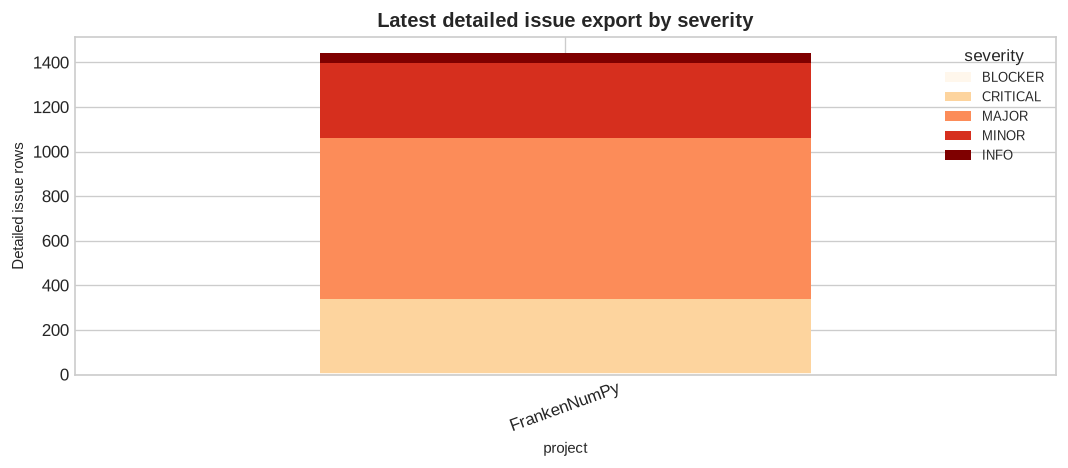

In [15]:
issue_frames = []
for project in PROJECTS:
    issues = latest_tables[project]["issues"].copy()
    if len(issues):
        issues["project"] = PROJECTS[project]["display"]
        issue_frames.append(issues)

if issue_frames:
    detailed_issues = pd.concat(issue_frames, ignore_index=True)
    severity_order = ["BLOCKER", "CRITICAL", "MAJOR", "MINOR", "INFO"]
    severity = (
        detailed_issues.groupby(["project", "severity"]).size()
        .unstack(fill_value=0).reindex(columns=severity_order, fill_value=0)
    )
    display(Markdown("**Latest exported issues by severity**"))
    display(severity)
    display(Markdown("**Most frequent rules in the latest populated export**"))
    display(
        detailed_issues.groupby(["rule_source", "rule", "severity"]).size()
        .rename("issues").sort_values(ascending=False).head(20).to_frame()
    )
    ax = severity.plot(kind="bar", stacked=True, figsize=(9, 4), colormap="OrRd")
    ax.set_ylabel("Detailed issue rows")
    ax.set_title("Latest detailed issue export by severity")
    ax.tick_params(axis="x", rotation=20)
    plt.tight_layout()
    plt.show()
else:
    display(Markdown("_No detailed issue rows are populated._"))

## 10. Reading the results against RQ4 hypotheses

### H4.1 — Higher commit volume is associated with broader/scattered commits

**Not testable from this extraction alone.** The notebook can describe `git_scattering`, co-change pairs, and churn aggregates, but it does not observe per-commit files/directories touched or a stable interval-specific commit volume. Moreover, batch-generated data, vendored trees, and build artifacts visibly dominate some scattering tails. A defensible test needs one row per commit with additions, deletions, files, top-level modules, timestamp, and an exclusion policy for generated/vendor paths.

### H4.2 — Agent-attributed commits are structurally cleaner

**Not testable from this extraction alone.** No agent attribution or commit-level cleanliness label is present. Join commit SHA to the agent-detection and commit/file-detail datasets, then compare distributions with project and time controls. Avoid treating “no hard signal” as “human-authored.”

### H4.3 — Sustained high-volume development accumulates complexity

**Partly describable, not causally established.** The density plots and endpoint/trend table show whether cyclomatic/cognitive complexity per KLOC and long-function tails rise within each project. Absolute complexity nearly always grows with NCLOC; density and tail measures are therefore more informative. A hypothesis test still needs commit-volume exposure, comparable observation windows, serial-correlation-aware models, and controls for language mix, generated/vendor content, and project maturation.

### ASAT lens

This is the extraction's strongest lens: normalized smells/violations, debt, ratings, bugs/vulnerabilities, duplication, comments, and file hotspots are all available over time. Quality-gate `ERROR` indicates the configured gate failed; it does not by itself quantify severity or prove poor external behavior.

## 11. Recommended paper-ready analyses and plots

The following outputs are defensible from the current data:

1. **Small multiples per project** (the six-panel profiles above), emphasizing within-project trajectories rather than raw cross-language comparisons.
2. **Complexity-versus-growth trajectories:** complexity and cognitive complexity per KLOC, with NCLOC growth shown separately.
3. **Maintainability burden:** violations and remediation effort per KLOC, plus comment/duplication density.
4. **Long-function tails:** p95/p99 and share above declared thresholds, only for languages covered by the function extractor.
5. **Hotspot concentration:** share of NCLOC, complexity, smells, or debt in the top 10 files; optionally raw versus source-like sensitivity.
6. **Scattering sensitivity:** raw and source-like co-change hotspots, explicitly flagging bulk generated/vendor/build/reference paths.
7. **Issue composition:** severity/rule plot only for datasets with populated detailed issue exports (currently FrankenNumPy).
8. **Sampling coverage rug/timeline:** necessary context because cadence and same-day multiplicity differ substantially.

Useful next extraction steps:

- add one commit table keyed by full SHA with additions, deletions, changed files, changed top-level directories, message/conventional type, tests touched, and agent signal;
- record the exact git-scattering definition and history window;
- import language-appropriate coverage/test reports into SonarQube;
- export detailed issues consistently for all projects;
- tag excluded/generated/vendor/reference paths in the extraction rather than only during analysis;
- preserve the full commit timestamp in filenames or a manifest and explain why some filename dates differ from `last_commit_date`.

## 12. Bottom line

The six-project extraction is rich enough for a credible longitudinal **code/ASAT quality** section and for exploratory **co-change coupling** analysis. Its strongest contribution is the combination of repository-, file-, function-, and issue-level snapshots. Its present limitation is equally clear: it is not yet a commit-quality dataset in the paper's operational sense. Commit size, breadth, focus, test coupling, and agent-attributed contrasts require a separate commit-level join.